# I. Combining Data

In [ ]:
import pandas as pd
import os

# List all csv file in the dataset folder
folder_path = '/content/drive/MyDrive/Bike_Share_Dataset'
all_files = os.listdir(folder_path)

# Check each file in all files has the same columns name
for f in all_files:
    df_temp = pd.read_csv(os.path.join(folder_path, f), nrows=0)
    print(f, list(df_temp.columns))

202508-divvy-tripdata.csv ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
202512-divvy-tripdata.csv ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
202511-divvy-tripdata.csv ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
202510-divvy-tripdata.csv ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']
202509-divvy-tripdata.csv ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_

In [ ]:
# Create a list of dataframes which each df is a csv file and then combine df in the list
df_list = []
# Using sorted() because all_files doesn't list the files in chronological order
for f in sorted(all_files):
  # Use os.path.join to create a full address for reading csv files because all_files just has the name of each csv files
  df_temp = pd.read_csv(os.path.join(folder_path, f))
  df_list.append(df_temp)

# Using ignore_index to avoid duplicated indices when combining many df
df = pd.concat(df_list, ignore_index=True)

df.head(20)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member
5,0B8DD16A9B77A1C7,electric_bike,2025-01-02 16:09:06.825,2025-01-02 16:10:55.784,Halsted St & 21st St,13162,Halsted St & 18th St,13099,41.853780,-87.646603,41.857506,-87.645991,member
6,65DD88D2EA5AA24A,electric_bike,2025-01-19 01:11:59.684,2025-01-19 01:15:54.187,Halsted St & Wrightwood Ave,TA1309000061,Southport Ave & Wrightwood Ave,TA1307000113,41.929143,-87.649077,41.928773,-87.663913,member
7,EAC4EE361C030130,electric_bike,2025-01-24 06:43:28.984,2025-01-24 07:01:38.943,Stave St & Armitage Ave,13266,Canal St & Madison St,13341,41.917741,-87.691392,41.882409,-87.639767,member
8,46267A54446162B5,electric_bike,2025-01-06 08:45:24.741,2025-01-06 08:50:20.458,Larrabee St & Kingsbury St,TA1306000009,Ogden Ave & Race Ave,13194,41.897764,-87.642884,41.891795,-87.658751,member
9,B5D4F9782121EA51,electric_bike,2025-01-01 16:56:36.927,2025-01-01 17:03:26.608,Albany Ave & Bloomingdale Ave,15655,Campbell Ave & Fullerton Ave,15648,41.914027,-87.705126,41.924632,-87.689307,member


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552994 entries, 0 to 5552993
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 550.8+ MB


# II. Cleaning

### 1. Missing values

In [ ]:
# Check columns that have missing value
df.isna().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,1184673
start_station_id,1184673
end_station_name,1243305
end_station_id,1243305
start_lat,0
start_lng,0


In [ ]:
# Delete rows that have missing 'end_lat' and 'end_lng' values
df = df.drop(df[(df['end_lat'].isna())].index)

In [ ]:
# Check again
len(df[df['end_lat'].isna()==True])

0

In [ ]:
# Filling 'Unknown' for missing values in 4 columns(start_station_id, start_station_name, end_station_id, end_station_name) to avoid errors when pushing to Bigquery
df['start_station_id'] = df['start_station_id'].fillna('Unknown')
df['start_station_name'] = df['start_station_name'].fillna('Unknown')
df['end_station_id'] = df['end_station_id'].fillna('Unknown')
df['end_station_name'] = df['end_station_name'].fillna('Unknown')

In [ ]:
df.isna().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,0
end_station_id,0
start_lat,0
start_lng,0


### 2. Data types

In [ ]:
# Change the time of start_at and end_at from object to datetime
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

### 3. Duplicated rows

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
# Check if ride_id is unique
print(df['ride_id'].duplicated().sum())

0


### 4. Checking for special characters

In [ ]:
# Check if are there any hidden newline characters that can cause errors when Bigquery parsing
hidden_newlines_s_name = df[df['start_station_name'].astype(str).str.contains(r'[\n\r]', regex=True)]
hidden_newlines_s_id = df[df['start_station_id'].astype(str).str.contains(r'[\n\r]', regex=True)]
hidden_newlines_e_name = df[df['end_station_name'].astype(str).str.contains(r'[\n\r]', regex=True)]
hidden_newlines_e_id = df[df['end_station_id'].astype(str).str.contains(r'[\n\r]', regex=True)]

print(f"Newline characters in start_station_name: {len(hidden_newlines_s_name)}")
print(f"Newline characters in start_station_id: {len(hidden_newlines_s_id)}")
print(f"Newline characters in end_station_name: {len(hidden_newlines_e_name)}")
print(f"Newline characters in end_station_id: {len(hidden_newlines_e_id)}")


Newline characters in start_station_name: 0
Newline characters in start_station_id: 0
Newline characters in end_station_name: 0
Newline characters in end_station_id: 0


### 5. Logic

In [ ]:
# Check that rideable_type column only contains 2 value (classic_bike and electric_bike)
print(df['rideable_type'].value_counts())
# Check that member_casual column only contains 2 value (member and casual)
print(df['member_casual'].value_counts())

rideable_type
electric_bike    3604953
classic_bike     1942506
Name: count, dtype: int64
member_casual
member    3552610
casual    1994849
Name: count, dtype: int64


In [ ]:
# Make sure that end_at is not before started_at
print((df['ended_at']<df['started_at']).sum())

29


In [ ]:
print(df[df['ended_at']<df['started_at']])

                  ride_id  rideable_type              started_at  \
5080953  5D010AFEA6850513  electric_bike 2025-11-02 01:52:37.475   
5082501  D1E5316AD88ECD45   classic_bike 2025-11-02 01:50:39.702   
5084495  3AF2F8908C9386F8   classic_bike 2025-11-02 01:57:57.512   
5099391  19386939ECD81B33  electric_bike 2025-11-02 01:55:34.399   
5107759  083534D28DA37F72   classic_bike 2025-11-02 01:17:57.001   
5152344  4A659F1BB40EDBF7  electric_bike 2025-11-02 01:55:38.177   
5177897  DA5386E5759667EC  electric_bike 2025-11-02 01:51:31.704   
5183355  985A3462DAACFFCF   classic_bike 2025-11-02 01:59:07.835   
5203278  434E3D11ABA96891  electric_bike 2025-11-02 01:59:40.156   
5213096  9288498F5630E3AD  electric_bike 2025-11-02 01:49:48.360   
5213113  12E0A9A586A45DE3  electric_bike 2025-11-02 01:49:41.788   
5214481  222A5E8650C55311  electric_bike 2025-11-02 01:55:51.266   
5223249  83995E751A0DB5D5  electric_bike 2025-11-02 01:50:50.530   
5256303  120BC0544C3B92E4   classic_bike 2025-11

In [ ]:
# Remove these rows
df = df[df['ended_at'] >= df['started_at']]

In [ ]:
print((df['ended_at']<df['started_at']).sum())

0


In [ ]:
# Check if lat/lng columns has inapprociate values
print(df[['start_lat', 'start_lng', 'end_lat', 'end_lng']].describe())
print((df[['start_lat', 'start_lng', 'end_lat', 'end_lng']] == 0).sum())

          start_lat     start_lng       end_lat       end_lng
count  5.547430e+06  5.547430e+06  5.547430e+06  5.547430e+06
mean   4.190368e+01 -8.764648e+01  4.190411e+01 -8.764683e+01
std    4.441521e-02  2.725199e-02  4.460470e-02  2.746624e-02
min    4.164850e+01 -8.789000e+01  4.149000e+01 -8.810000e+01
25%    4.188213e+01 -8.766000e+01  4.188241e+01 -8.766000e+01
50%    4.189859e+01 -8.764182e+01  4.189964e+01 -8.764275e+01
75%    4.193000e+01 -8.762991e+01  4.193000e+01 -8.763000e+01
max    4.207000e+01 -8.752000e+01  4.221000e+01 -8.742000e+01
start_lat    0
start_lng    0
end_lat      0
end_lng      0
dtype: int64


# III. Transforming

* Note: This Haversine distance reflects straight-line distance, not the actual bike route distance.

In [ ]:
# Calculating ride distance using Haversine
import numpy as np

def haversine_distance(lat1, lng1, lat2, lng2):
    R = 6371  # Earth's radius (km)

    # Change to radian (Haversine requires radian values)
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])

    dlat = lat2 - lat1
    dlng = lng2 - lng1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    distance = R * c
    return distance

In [ ]:
# Adding ride_distance_km column
df['ride_distance_km'] = haversine_distance(
    df['start_lat'],
    df['start_lng'],
    df['end_lat'],
    df['end_lng']
)

In [ ]:
df.head(10)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_distance_km
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,1.957540
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,1.426012
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,1.488752
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950
5,0B8DD16A9B77A1C7,electric_bike,2025-01-02 16:09:06.825,2025-01-02 16:10:55.784,Halsted St & 21st St,13162,Halsted St & 18th St,13099,41.853780,-87.646603,41.857506,-87.645991,member,0.417382
6,65DD88D2EA5AA24A,electric_bike,2025-01-19 01:11:59.684,2025-01-19 01:15:54.187,Halsted St & Wrightwood Ave,TA1309000061,Southport Ave & Wrightwood Ave,TA1307000113,41.929143,-87.649077,41.928773,-87.663913,member,1.228014
7,EAC4EE361C030130,electric_bike,2025-01-24 06:43:28.984,2025-01-24 07:01:38.943,Stave St & Armitage Ave,13266,Canal St & Madison St,13341,41.917741,-87.691392,41.882409,-87.639767,member,5.804368
8,46267A54446162B5,electric_bike,2025-01-06 08:45:24.741,2025-01-06 08:50:20.458,Larrabee St & Kingsbury St,TA1306000009,Ogden Ave & Race Ave,13194,41.897764,-87.642884,41.891795,-87.658751,member,1.471507
9,B5D4F9782121EA51,electric_bike,2025-01-01 16:56:36.927,2025-01-01 17:03:26.608,Albany Ave & Bloomingdale Ave,15655,Campbell Ave & Fullerton Ave,15648,41.914027,-87.705126,41.924632,-87.689307,member,1.761797


In [ ]:
# Calculating ride length
df['ride_length'] = df['ended_at'] - df['started_at']
# Converting ride length to minutes (float) to avoid errors when BigQuery parse
df['ride_length_min'] = df['ride_length'].dt.total_seconds() / 60
# Drop ride_length
df = df.drop(['ride_length'], axis = 1)
df.head(20)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_distance_km,ride_length_min
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,1.957540,13.957950
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,1.426012,5.072400
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,1.488752,11.591667
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950,3.570550
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950,2.573817
5,0B8DD16A9B77A1C7,electric_bike,2025-01-02 16:09:06.825,2025-01-02 16:10:55.784,Halsted St & 21st St,13162,Halsted St & 18th St,13099,41.853780,-87.646603,41.857506,-87.645991,member,0.417382,1.815983
6,65DD88D2EA5AA24A,electric_bike,2025-01-19 01:11:59.684,2025-01-19 01:15:54.187,Halsted St & Wrightwood Ave,TA1309000061,Southport Ave & Wrightwood Ave,TA1307000113,41.929143,-87.649077,41.928773,-87.663913,member,1.228014,3.908383
7,EAC4EE361C030130,electric_bike,2025-01-24 06:43:28.984,2025-01-24 07:01:38.943,Stave St & Armitage Ave,13266,Canal St & Madison St,13341,41.917741,-87.691392,41.882409,-87.639767,member,5.804368,18.165983
8,46267A54446162B5,electric_bike,2025-01-06 08:45:24.741,2025-01-06 08:50:20.458,Larrabee St & Kingsbury St,TA1306000009,Ogden Ave & Race Ave,13194,41.897764,-87.642884,41.891795,-87.658751,member,1.471507,4.928617
9,B5D4F9782121EA51,electric_bike,2025-01-01 16:56:36.927,2025-01-01 17:03:26.608,Albany Ave & Bloomingdale Ave,15655,Campbell Ave & Fullerton Ave,15648,41.914027,-87.705126,41.924632,-87.689307,member,1.761797,6.828017


In [ ]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_distance_km,ride_length_min
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,1.957540,13.957950
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,1.426012,5.072400
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,1.488752,11.591667
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950,3.570550
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950,2.573817


In [ ]:
# Creating day_of_week mapping (1: Sunday -> 7: Saturday)
day_map = {
    'Sunday': '1. Sunday',
    'Monday': '2. Monday',
    'Tuesday': '3. Tuesday',
    'Wednesday': '4. Wednesday',
    'Thursday': '5. Thursday',
    'Friday': '6. Friday',
    'Saturday': '7. Saturday'
}

# Creating day_of_week column
df['day_of_week'] = df['started_at'].dt.day_name().map(day_map)
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_distance_km,ride_length_min,day_of_week
0,7569BC890583FCD7,classic_bike,2025-01-21 17:23:54.538,2025-01-21 17:37:52.015,Wacker Dr & Washington St,KA1503000072,McClurg Ct & Ohio St,TA1306000029,41.883143,-87.637242,41.892592,-87.617289,member,1.957540,13.957950,3. Tuesday
1,013609308856B7FC,electric_bike,2025-01-11 15:44:06.795,2025-01-11 15:49:11.139,Halsted St & Wrightwood Ave,TA1309000061,Racine Ave & Belmont Ave,TA1308000019,41.929147,-87.649153,41.939743,-87.658865,member,1.426012,5.072400,7. Saturday
2,EACACD3CE0607C0D,classic_bike,2025-01-02 15:16:27.730,2025-01-02 15:28:03.230,Southport Ave & Waveland Ave,13235,Broadway & Cornelia Ave,13278,41.948226,-87.664071,41.945529,-87.646439,member,1.488752,11.591667,5. Thursday
3,EAA2485BA64710D3,classic_bike,2025-01-23 08:49:05.814,2025-01-23 08:52:40.047,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950,3.570550,5. Thursday
4,7F8BE2471C7F746B,electric_bike,2025-01-16 08:38:32.338,2025-01-16 08:41:06.767,Southport Ave & Waveland Ave,13235,Southport Ave & Roscoe St,13071,41.948226,-87.664071,41.943739,-87.664020,member,0.498950,2.573817,5. Thursday


# IV. Statistics

In [ ]:
df.describe()

,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,ride_distance_km,ride_length_min
count,5547430,5547430,5.547430e+06,5.547430e+06,5.547430e+06,5.547430e+06,5.547430e+06,5.547430e+06
mean,2025-07-20 19:11:44.870849792,2025-07-20 19:26:19.299973120,4.190368e+01,-8.764648e+01,4.190411e+01,-8.764683e+01,2.202802e+00,1.457382e+01
min,2024-12-31 18:54:41.803000,2025-01-01 00:00:01.447000,4.164850e+01,-8.789000e+01,4.149000e+01,-8.810000e+01,0.000000e+00,7.666667e-04
25%,2025-05-28 08:59:15.019749888,2025-05-28 09:08:57.966499840,4.188213e+01,-8.766000e+01,4.188241e+01,-8.766000e+01,9.081145e-01,5.391521e+00
50%,2025-07-26 17:19:04.402499840,2025-07-26 17:37:58.496999936,4.189859e+01,-8.764182e+01,4.189964e+01,-8.764275e+01,1.615363e+00,9.416683e+00
75%,2025-09-21 06:20:36.693750016,2025-09-21 06:39:48.852000,4.193000e+01,-8.762991e+01,4.193000e+01,-8.763000e+01,2.879212e+00,1.653011e+01
max,2025-12-31 23:53:24.274000,2025-12-31 23:58:42.046000,4.207000e+01,-8.752000e+01,4.221000e+01,-8.742000e+01,4.056503e+01,1.499968e+03
std,NaN,NaN,4.441521e-02,2.725199e-02,4.460470e-02,2.746624e-02,1.994844e+00,2.977840e+01


In [ ]:
print(f"Skew: {df['ride_length_min'].skew():.2f}")
print(f"Skew: {df['ride_distance_km'].skew():.2f}")
print(f"Kurt: {df['ride_length_min'].kurt():.2f}")
print(f"Kurt: {df['ride_distance_km'].kurt():.2f}")


Skew: 25.56
Skew: 2.18
Kurt: 961.72
Kurt: 8.06


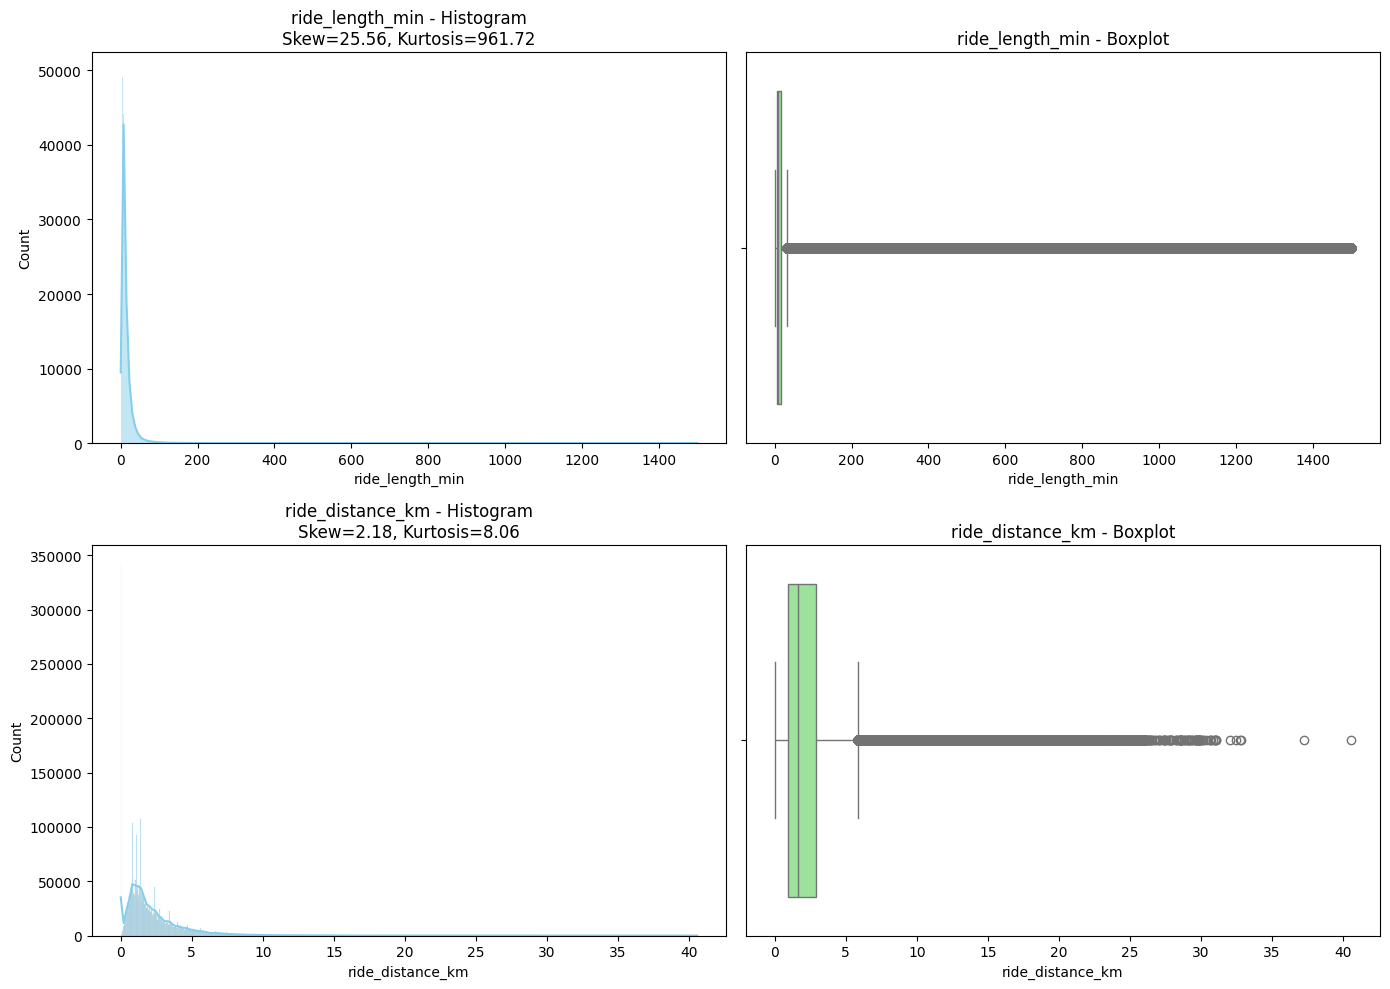

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

cols = ['ride_length_min', 'ride_distance_km']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(cols):
    skew_val = df[col].skew()
    kurt_val = df[col].kurt()

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} - Histogram\nSkew={skew_val:.2f}, Kurtosis={kurt_val:.2f}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

Conclusion: Positively Skewed and Leptokurtic distribution => There are also a lot of outliers that need to be considered

In [ ]:
# Find outliers using IQR
Q1 = df['ride_distance_km'].quantile(0.25)
Q3 = df['ride_distance_km'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 = {Q1}")
print(f"Q3 = {Q3}")
print(f"IQR = {IQR}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['ride_distance_km'] < lower_bound) | (df['ride_distance_km'] > upper_bound)]
print(outliers)

Q1 = 0.9081145322790574
Q3 = 2.8792120090773228
IQR = 1.9710974767982654
                  ride_id  rideable_type              started_at  \
31       0B6242FC5805AB59  electric_bike 2025-01-28 12:28:17.902   
40       2FA0F717FE44CBFC  electric_bike 2025-01-16 11:54:17.237   
62       5E5E512A88BE5333   classic_bike 2025-01-23 21:55:07.720   
63       DDF68A146CABD59D   classic_bike 2025-01-12 00:09:38.866   
122      B099B829140F9EDC   classic_bike 2025-01-26 14:59:16.167   
...                   ...            ...                     ...   
5552881  4CCA5EBBC92BC089  electric_bike 2025-12-11 17:38:20.187   
5552903  8516FF033843AA26   classic_bike 2025-12-20 13:07:43.085   
5552949  D1FE2D5F6522A9FB  electric_bike 2025-12-27 16:04:52.507   
5552950  3C326B2BA6A1DFEB  electric_bike 2025-12-01 10:27:48.988   
5552952  1EF2651490898AE1  electric_bike 2025-12-25 16:15:25.601   

                       ended_at                   start_station_name  \
31      2025-01-28 12:50:00.973       

Conclusion: These outliers reflect some possible real-life scenarios so they shouldn't be deleted

### Logic

In [ ]:
# Find trips that have ride distance = 0 (start_lat=end_lat and start_lng=end_lng), which are unreasonable
print(df[df['ride_distance_km'] == 0].sort_values('ride_length_min', ascending=False))

                  ride_id  rideable_type              started_at  \
5136966  30D326B2DF3A586B   classic_bike 2025-11-10 08:03:20.564   
1802047  DD6CE61F6EB12EB4   classic_bike 2025-06-26 18:23:01.403   
3248500  B9768851A8E6AB91   classic_bike 2025-08-20 13:00:56.115   
3281486  CB2D69C174DE8263   classic_bike 2025-08-16 12:28:37.857   
1468973  CDC926E3C87710F4   classic_bike 2025-06-14 19:46:18.795   
...                   ...            ...                     ...   
5547740  8E8BD2EB7344E23F  electric_bike 2025-12-04 17:29:41.963   
2951760  DBA263759634C83B  electric_bike 2025-08-02 21:53:52.946   
2108339  82D62BB042C28F8D  electric_bike 2025-06-01 04:27:50.958   
391469   5D05D9E43D1B3981  electric_bike 2025-03-10 17:33:44.961   
314381   5D2C2EBE84C1D1BA  electric_bike 2025-03-13 07:17:06.940   

                       ended_at        start_station_name start_station_id  \
5136966 2025-11-11 09:01:47.465   Clinton St & Madison St         CHI00233   
1802047 2025-06-27 19:16:21

In [ ]:
# Delete these rows
df = df.drop(df[df['ride_distance_km']==0].index)
print(sum(df['ride_distance_km']==0))

0


 Divvy document (https://divvybikes.com/system-data) said that "Any trips that were below 60 seconds in length (potentially false starts or users trying to re-dock a bike to ensure it was secure)".

In [ ]:
# Find trips have ride_length lower than 1 min
print(df[(df['ride_length_min'] < 1)].sort_values('ride_length_min', ascending=False))

                  ride_id  rideable_type              started_at  \
2805998  5BB85DC1F5DA6F23  electric_bike 2025-07-06 20:50:36.081   
3744360  73EF18FBC7B0243B  electric_bike 2025-09-04 21:35:45.245   
3127124  786CEA6120FEA81C  electric_bike 2025-08-04 13:37:52.697   
4881508  2F77685E0821BB94  electric_bike 2025-10-05 11:38:15.849   
5488527  9F71AB6AA934CB51  electric_bike 2025-12-26 13:34:21.474   
...                   ...            ...                     ...   
3501982  5DDB29218284AF95  electric_bike 2025-08-07 16:14:55.897   
830527   9A7F5515E2EEBE04  electric_bike 2025-04-27 17:43:19.898   
3693296  88CD07540F6AC3ED  electric_bike 2025-08-31 16:28:33.904   
3389368  A8FDB4B23714AAFD  electric_bike 2025-08-28 12:22:57.917   
4325560  875C43D2EE759DA8  electric_bike 2025-09-17 10:18:35.965   

                       ended_at            start_station_name  \
2805998 2025-07-06 20:51:36.072                       Unknown   
3744360 2025-09-04 21:36:45.233       Wilton Ave & Ad

In [ ]:
# Delete this rows
df = df.drop(df[(df['ride_length_min']<1)].index)
print(sum((df['ride_length_min']<1)))

0


In [ ]:
df.describe()

,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,ride_distance_km,ride_length_min
count,5174009,5174009,5.174009e+06,5.174009e+06,5.174009e+06,5.174009e+06,5.174009e+06,5.174009e+06
mean,2025-07-20 14:46:21.782498560,2025-07-20 15:00:48.541702912,4.190388e+01,-8.764666e+01,4.190434e+01,-8.764703e+01,2.359233e+00,1.444599e+01
min,2024-12-31 18:54:41.803000,2025-01-01 00:00:01.447000,4.164850e+01,-8.789000e+01,4.149000e+01,-8.810000e+01,2.037112e-04,1.000017e+00
25%,2025-05-27 13:18:33.871000064,2025-05-27 13:32:55.931000064,4.188241e+01,-8.766000e+01,4.188266e+01,-8.766000e+01,1.050606e+00,5.753017e+00
50%,2025-07-26 17:28:08.116999936,2025-07-26 17:45:30.851000064,4.189897e+01,-8.764274e+01,4.189993e+01,-8.764299e+01,1.726783e+00,9.659950e+00
75%,2025-09-21 13:03:59.121999872,2025-09-21 13:22:23.176999936,4.193000e+01,-8.763000e+01,4.193000e+01,-8.763000e+01,3.021425e+00,1.653507e+01
max,2025-12-31 23:53:24.274000,2025-12-31 23:58:42.046000,4.207000e+01,-8.752000e+01,4.221000e+01,-8.742000e+01,4.056503e+01,1.499968e+03
std,NaN,NaN,4.379868e-02,2.681953e-02,4.400210e-02,2.704930e-02,1.975316e+00,2.797594e+01


# V. Push to BigQuery


In [ ]:
!pip install pandas-gbq --quiet

In [ ]:
# Push dataframe to BigQuery
import pandas_gbq

project_id = 'cyclistic-case-study-509605'
dataset_table = 'cyclistic_data.trips'  # format: dataset_name.table_name

pandas_gbq.to_gbq(
    df,
    destination_table=dataset_table,
    project_id=project_id,
    if_exists='replace'   # 'replace' = override data if it already existed, 'append' = add new data
)

print("Successful!")

100%|██████████| 1/1 [00:00<00:00, 7384.34it/s]

Successful!
